# Phase 4A — Drift Validation and Temporal-Gap Audit

## Aim

Before estimating or correcting drift, this notebook verifies that the
existing displacement steps correspond to the intended physical frame lags.

The current implementation uses row-based shifting within each trajectory.
If a trajectory contains missing frames, a one-row shift may represent more
than one physical frame.

This notebook will:

1. load and validate the cleaned trajectories;
2. detect duplicate cell-frame observations;
3. measure frame and time gaps inside each trajectory;
4. compare labeled lag values with actual frame differences;
5. determine whether the Phase 3 step implementation requires correction;
6. proceed to drift validation only after the lag definition is verified.

In [1]:
import _path
from _path import PROJECT_ROOT

import numpy as np
import pandas as pd

from src.steps import (
    compute_steps_multi_tau,
    summary_by_tau,
    validate_tracks,
)

TRACKS_PATH = PROJECT_ROOT / "data" / "MSC01_tracks_clean.csv"

print("Project root:", PROJECT_ROOT)
print("Input file:", TRACKS_PATH)
print("Input exists:", TRACKS_PATH.exists())

Project root: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility
Input file: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility\data\MSC01_tracks_clean.csv
Input exists: True


In [2]:
tracks = pd.read_csv(TRACKS_PATH)

validate_tracks(tracks)

print("Shape:", tracks.shape)
print("Number of cells:", tracks["cell_id"].nunique())
print("Frame range:", tracks["frame"].min(), "to", tracks["frame"].max())

display(tracks.head())
display(tracks.dtypes)

Shape: (474, 5)
Number of cells: 35
Frame range: 0 to 47


,cell_id,frame,t_min,x_um,y_um
0,0,10,200.0,39.867660,224.393768
1,0,11,220.0,34.776408,227.566565
2,0,12,240.0,31.056212,229.721570
3,0,13,260.0,32.449259,230.256018
4,0,14,280.0,33.368621,230.260754


cell_id      int64
frame        int64
t_min      float64
x_um       float64
y_um       float64
dtype: object

In [3]:
duplicate_mask = tracks.duplicated(
    subset=["cell_id", "frame"],
    keep=False,
)

n_duplicate_rows = int(duplicate_mask.sum())

print("Duplicate cell-frame rows:", n_duplicate_rows)

if n_duplicate_rows > 0:
    display(
        tracks.loc[duplicate_mask]
        .sort_values(["cell_id", "frame"])
    )

Duplicate cell-frame rows: 0


In [4]:
tracks_sorted = (
    tracks
    .sort_values(["cell_id", "frame"])
    .reset_index(drop=True)
    .copy()
)

grouped_tracks = tracks_sorted.groupby(
    "cell_id",
    sort=False,
)

tracks_sorted["frame_gap"] = (
    grouped_tracks["frame"]
    .diff()
    .astype("Int64")
)

tracks_sorted["time_gap_min"] = (
    grouped_tracks["t_min"]
    .diff()
)

gap_counts = (
    tracks_sorted
    .dropna(subset=["frame_gap"])
    .groupby(["frame_gap", "time_gap_min"])
    .size()
    .rename("n_transitions")
    .reset_index()
    .sort_values(["frame_gap", "time_gap_min"])
)

display(gap_counts)

,frame_gap,time_gap_min,n_transitions
0,1,20.0,433
1,2,40.0,6


In [5]:
gap_audit = (
    tracks_sorted
    .dropna(subset=["frame_gap", "time_gap_min"])
    .loc[:, ["cell_id", "frame", "frame_gap", "time_gap_min"]]
    .copy()
)

gap_audit["expected_time_gap_min"] = (
    gap_audit["frame_gap"] * 20.0
)

gap_audit["time_is_consistent"] = np.isclose(
    gap_audit["time_gap_min"],
    gap_audit["expected_time_gap_min"],
)

print(
    "Transitions with inconsistent frame/time calibration:",
    int((~gap_audit["time_is_consistent"]).sum()),
)

display(
    gap_audit.loc[~gap_audit["time_is_consistent"]].head(20)
)

Transitions with inconsistent frame/time calibration: 0


,cell_id,frame,frame_gap,time_gap_min,expected_time_gap_min,time_is_consistent


In [6]:
taus = [1, 2, 4]

steps_current = compute_steps_multi_tau(
    tracks,
    taus=taus,
).copy()

steps_current["actual_frame_gap"] = (
    steps_current["frame_end"]
    - steps_current["frame_start"]
)

steps_current["lag_matches_label"] = (
    steps_current["actual_frame_gap"]
    == steps_current["tau_frames"]
)

lag_audit = (
    steps_current
    .groupby(["tau_frames", "actual_frame_gap"])
    .size()
    .rename("n_steps")
    .reset_index()
    .sort_values(["tau_frames", "actual_frame_gap"])
)

display(lag_audit)

,tau_frames,actual_frame_gap,n_steps
0,1,1,433
1,2,2,398
2,4,4,343


In [7]:
lag_summary = (
    steps_current
    .groupby("tau_frames")
    .agg(
        n_steps=("cell_id", "size"),
        n_matching=("lag_matches_label", "sum"),
    )
    .reset_index()
)

lag_summary["n_mismatched"] = (
    lag_summary["n_steps"]
    - lag_summary["n_matching"]
)

lag_summary["percent_mismatched"] = (
    100
    * lag_summary["n_mismatched"]
    / lag_summary["n_steps"]
)

display(lag_summary)

total_mismatched = int(
    (~steps_current["lag_matches_label"]).sum()
)

print("Total mislabeled-lag steps:", total_mismatched)

,tau_frames,n_steps,n_matching,n_mismatched,percent_mismatched
0,1,433,433,0,0.0
1,2,398,398,0,0.0
2,4,343,343,0,0.0


Total mislabeled-lag steps: 0


In [8]:
taus = [1, 2, 4]

# Build displacement steps using the corrected exact-frame implementation.
steps_exact = compute_steps_multi_tau(
    tracks,
    taus=taus,
).copy()

steps_exact["actual_frame_gap"] = (
    steps_exact["frame_end"]
    - steps_exact["frame_start"]
)

steps_exact["lag_matches_label"] = (
    steps_exact["actual_frame_gap"]
    == steps_exact["tau_frames"]
)

lag_audit_exact = (
    steps_exact
    .groupby(
        ["tau_frames", "actual_frame_gap"]
    )
    .size()
    .rename("n_steps")
    .reset_index()
    .sort_values(
        ["tau_frames", "actual_frame_gap"]
    )
)

display(lag_audit_exact)

lag_summary_exact = (
    steps_exact
    .groupby("tau_frames")
    .agg(
        n_steps=("cell_id", "size"),
        n_cells=("cell_id", "nunique"),
        n_matching=("lag_matches_label", "sum"),
        median_tau_min=("tau_min", "median"),
    )
    .reset_index()
)

lag_summary_exact["n_mismatched"] = (
    lag_summary_exact["n_steps"]
    - lag_summary_exact["n_matching"]
)

lag_summary_exact["percent_mismatched"] = (
    100
    * lag_summary_exact["n_mismatched"]
    / lag_summary_exact["n_steps"]
)

display(lag_summary_exact)

total_mismatched = int(
    (~steps_exact["lag_matches_label"]).sum()
)

print(
    "Total mismatched steps:",
    total_mismatched,
)

,tau_frames,actual_frame_gap,n_steps
0,1,1,433
1,2,2,398
2,4,4,343


,tau_frames,n_steps,n_cells,n_matching,median_tau_min,n_mismatched,percent_mismatched
0,1,433,35,433,20.0,0,0.0
1,2,398,32,398,40.0,0,0.0
2,4,343,26,343,80.0,0,0.0


Total mismatched steps: 0


In [9]:
tau1_steps = (
    steps_exact
    .loc[
        steps_exact["tau_frames"].eq(1)
    ]
    .copy()
)

print(
    "Number of exact tau=1 steps:",
    len(tau1_steps),
)

print(
    "Number of contributing cells:",
    tau1_steps["cell_id"].nunique(),
)

display(tau1_steps.head())

Number of exact tau=1 steps: 433
Number of contributing cells: 35


,cell_id,frame_start,t_start_min,frame_end,t_end_min,dx_um,dy_um,tau_frames,tau_min,actual_frame_gap,lag_matches_label
0,0,10,200.0,11,220.0,-5.091252,3.172796,1,20.0,1,True
1,0,11,220.0,12,240.0,-3.720196,2.155006,1,20.0,1,True
2,0,12,240.0,13,260.0,1.393048,0.534448,1,20.0,1,True
3,0,13,260.0,14,280.0,0.919362,0.004737,1,20.0,1,True
4,1,0,0.0,1,20.0,-1.043849,0.011084,1,20.0,1,True


## Phase 4B — Frame-wise Common-Motion Analysis

We now estimate the displacement component shared by cells during each
consecutive-frame transition.

At this stage, the estimate is called **common motion**, not microscope drift.
A shared displacement could result from:

- microscope-stage or image drift;
- motion of the entire sample;
- collective biological migration;
- or a mixture of technical and biological effects.

No coordinate correction will be applied until the common-motion pattern is
validated.

In [10]:
def median_absolute_deviation(
    values: pd.Series,
) -> float:
    """Return the unscaled median absolute deviation."""
    array = values.to_numpy(dtype=float)

    median_value = np.median(array)

    absolute_deviations = np.abs(
        array - median_value
    )

    return float(
        np.median(absolute_deviations)
    )

In [11]:
framewise_motion = (
    tau1_steps
    .groupby(
        ["frame_start", "frame_end"],
        as_index=False,
    )
    .agg(
        n_cells=("cell_id", "size"),
        mean_dx_um=("dx_um", "mean"),
        mean_dy_um=("dy_um", "mean"),
        median_dx_um=("dx_um", "median"),
        median_dy_um=("dy_um", "median"),
        mad_dx_um=(
            "dx_um",
            median_absolute_deviation,
        ),
        mad_dy_um=(
            "dy_um",
            median_absolute_deviation,
        ),
    )
    .sort_values("frame_start")
    .reset_index(drop=True)
)

framewise_motion["common_magnitude_um"] = np.hypot(
    framewise_motion["median_dx_um"],
    framewise_motion["median_dy_um"],
)

framewise_motion["cumulative_dx_um"] = (
    framewise_motion["median_dx_um"].cumsum()
)

framewise_motion["cumulative_dy_um"] = (
    framewise_motion["median_dy_um"].cumsum()
)

display(framewise_motion)

,frame_start,frame_end,n_cells,mean_dx_um,mean_dy_um,median_dx_um,median_dy_um,mad_dx_um,mad_dy_um,common_magnitude_um,cumulative_dx_um,cumulative_dy_um
0,0,1,8,0.796851,0.568235,0.474695,0.265963,1.577500,0.974722,0.544125,0.474695,0.265963
1,1,2,7,0.455238,-0.654255,0.130278,-0.169187,0.801906,0.652402,0.213533,0.604973,0.096776
2,2,3,7,-0.276692,0.883282,-0.982524,0.893830,0.621998,0.771806,1.328265,-0.377551,0.990606
3,3,4,9,0.005570,1.221847,0.042213,0.978444,0.885346,0.750423,0.979354,-0.335339,1.969050
4,4,5,9,0.071343,1.173551,0.000000,0.217583,1.460360,0.466477,0.217583,-0.335339,2.186633
5,5,6,9,-0.657037,1.734253,0.661268,1.158856,0.659151,1.158856,1.334250,0.325929,3.345489
6,6,7,9,0.250977,0.439710,0.300000,0.460676,1.028638,0.833767,0.549747,0.625929,3.806165
7,7,8,9,1.176699,-0.195075,0.880043,-0.063465,0.490572,1.123016,0.882329,1.505973,3.742701
8,8,9,8,1.166270,0.824163,0.264566,0.354972,1.374218,2.163498,0.442719,1.770539,4.097672
9,9,10,6,-0.077642,-0.147675,0.085349,-0.215067,1.694677,2.218151,0.231384,1.855888,3.882605


In [12]:
expected_transitions = pd.DataFrame(
    {
        "frame_start": range(
            int(tracks["frame"].min()),
            int(tracks["frame"].max()),
        )
    }
)

expected_transitions["frame_end"] = (
    expected_transitions["frame_start"] + 1
)

transition_coverage = expected_transitions.merge(
    framewise_motion[
        ["frame_start", "frame_end", "n_cells"]
    ],
    on=["frame_start", "frame_end"],
    how="left",
    validate="one_to_one",
)

missing_transitions = transition_coverage.loc[
    transition_coverage["n_cells"].isna()
].copy()

print(
    "Expected consecutive-frame transitions:",
    len(expected_transitions),
)

print(
    "Observed consecutive-frame transitions:",
    len(framewise_motion),
)

print(
    "Transitions without any exact tau=1 step:",
    len(missing_transitions),
)

display(missing_transitions)

Expected consecutive-frame transitions: 47
Observed consecutive-frame transitions: 47
Transitions without any exact tau=1 step: 0


,frame_start,frame_end,n_cells


In [13]:
print(
    "Cells per transition — min / median / max:",
    int(framewise_motion["n_cells"].min()),
    float(framewise_motion["n_cells"].median()),
    int(framewise_motion["n_cells"].max()),
)

print(
    "Median frame-wise common dx:",
    framewise_motion["median_dx_um"].median(),
)

print(
    "Median frame-wise common dy:",
    framewise_motion["median_dy_um"].median(),
)

print(
    "Final cumulative common dx:",
    framewise_motion["cumulative_dx_um"].iloc[-1],
)

print(
    "Final cumulative common dy:",
    framewise_motion["cumulative_dy_um"].iloc[-1],
)

print(
    "Fraction of transitions with negative median dx:",
    (
        framewise_motion["median_dx_um"] < 0
    ).mean(),
)

print(
    "Fraction of transitions with negative median dy:",
    (
        framewise_motion["median_dy_um"] < 0
    ).mean(),
)

display(
    framewise_motion[
        [
            "n_cells",
            "median_dx_um",
            "median_dy_um",
            "mad_dx_um",
            "mad_dy_um",
            "common_magnitude_um",
        ]
    ].describe()
)

Cells per transition — min / median / max: 6 9.0 12
Median frame-wise common dx: -0.3000000117187369
Median frame-wise common dy: 0.0
Final cumulative common dx: -16.746816703800093
Final cumulative common dy: 3.071543035564602
Fraction of transitions with negative median dx: 0.6170212765957447
Fraction of transitions with negative median dy: 0.3404255319148936


,n_cells,median_dx_um,median_dy_um,mad_dx_um,mad_dy_um,common_magnitude_um
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000
mean,9.212766,-0.356315,0.065352,1.152749,0.828614,0.738031
std,1.267249,0.661698,0.425441,0.438314,0.431241,0.443169
min,6.000000,-1.832771,-1.052927,0.490572,0.047305,0.000000
25%,9.000000,-0.802840,-0.078699,0.813746,0.529643,0.372470
50%,9.000000,-0.300000,0.000000,1.142182,0.771806,0.724896
75%,10.000000,0.107813,0.268357,1.523777,0.973372,1.089256
max,12.000000,0.880043,1.158856,2.293100,2.218151,1.832771


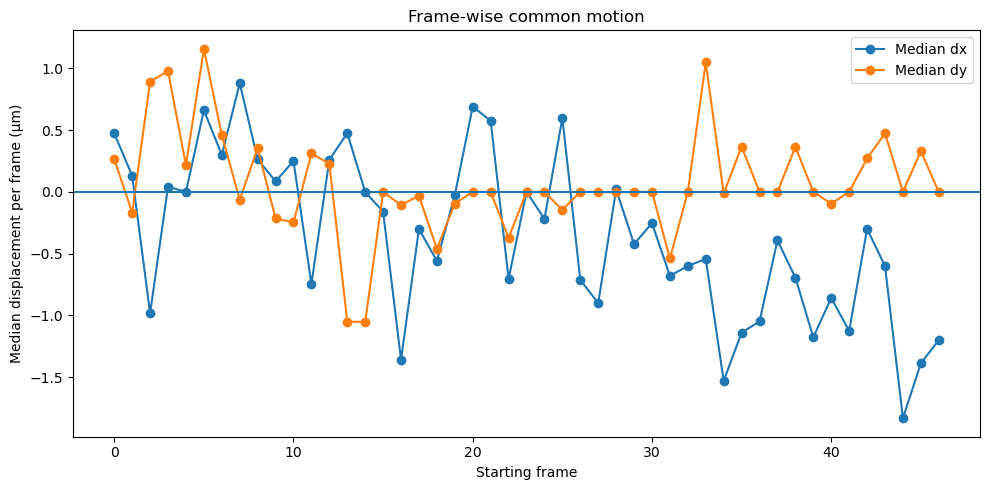

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    framewise_motion["frame_start"],
    framewise_motion["median_dx_um"],
    marker="o",
    label="Median dx",
)

plt.plot(
    framewise_motion["frame_start"],
    framewise_motion["median_dy_um"],
    marker="o",
    label="Median dy",
)

plt.axhline(0)

plt.xlabel("Starting frame")
plt.ylabel("Median displacement per frame (µm)")
plt.title("Frame-wise common motion")
plt.legend()
plt.tight_layout()
plt.show()

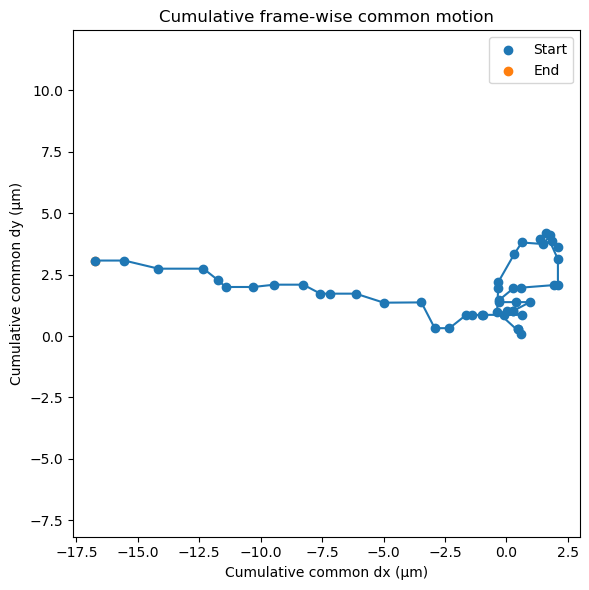

In [15]:
plt.figure(figsize=(6, 6))

plt.plot(
    framewise_motion["cumulative_dx_um"],
    framewise_motion["cumulative_dy_um"],
    marker="o",
)

plt.scatter(
    framewise_motion["cumulative_dx_um"].iloc[0],
    framewise_motion["cumulative_dy_um"].iloc[0],
    label="Start",
)

plt.scatter(
    framewise_motion["cumulative_dx_um"].iloc[-1],
    framewise_motion["cumulative_dy_um"].iloc[-1],
    label="End",
)

plt.xlabel("Cumulative common dx (µm)")
plt.ylabel("Cumulative common dy (µm)")
plt.title("Cumulative frame-wise common motion")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
tau1_centered = tau1_steps.merge(
    framewise_motion[
        [
            "frame_start",
            "frame_end",
            "median_dx_um",
            "median_dy_um",
        ]
    ],
    on=["frame_start", "frame_end"],
    how="left",
    validate="many_to_one",
)

tau1_centered["residual_dx_um"] = (
    tau1_centered["dx_um"]
    - tau1_centered["median_dx_um"]
)

tau1_centered["residual_dy_um"] = (
    tau1_centered["dy_um"]
    - tau1_centered["median_dy_um"]
)

comparison = pd.DataFrame(
    {
        "raw_mean": [
            tau1_centered["dx_um"].mean(),
            tau1_centered["dy_um"].mean(),
        ],
        "raw_median": [
            tau1_centered["dx_um"].median(),
            tau1_centered["dy_um"].median(),
        ],
        "residual_mean": [
            tau1_centered["residual_dx_um"].mean(),
            tau1_centered["residual_dy_um"].mean(),
        ],
        "residual_median": [
            tau1_centered["residual_dx_um"].median(),
            tau1_centered["residual_dy_um"].median(),
        ],
    },
    index=["dx_um", "dy_um"],
)

display(comparison)

,raw_mean,raw_median,residual_mean,residual_median
dx_um,-0.449440,-0.483247,-0.072486,0.0
dy_um,-0.064475,0.000000,-0.126184,0.0


In [17]:
frame_correction = pd.DataFrame(
    {
        "frame": [int(tracks["frame"].min())],
        "common_x_um": [0.0],
        "common_y_um": [0.0],
    }
)

cumulative_part = pd.DataFrame(
    {
        "frame": framewise_motion["frame_end"],
        "common_x_um": (
            framewise_motion["median_dx_um"].cumsum()
        ),
        "common_y_um": (
            framewise_motion["median_dy_um"].cumsum()
        ),
    }
)

frame_correction = pd.concat(
    [frame_correction, cumulative_part],
    ignore_index=True,
)

display(frame_correction.head())
display(frame_correction.tail())

,frame,common_x_um,common_y_um
0,0,0.000000,0.000000
1,1,0.474695,0.265963
2,2,0.604973,0.096776
3,3,-0.377551,0.990606
4,4,-0.335339,1.969050


,frame,common_x_um,common_y_um
43,43,-11.726306,2.266266
44,44,-12.326306,2.740747
45,45,-14.159077,2.740747
46,46,-15.546817,3.071543
47,47,-16.746817,3.071543


In [18]:
tracks_comoving = tracks.merge(
    frame_correction,
    on="frame",
    how="left",
    validate="many_to_one",
)

tracks_comoving["x_um_raw"] = tracks_comoving["x_um"]
tracks_comoving["y_um_raw"] = tracks_comoving["y_um"]

tracks_comoving["x_um"] = (
    tracks_comoving["x_um"]
    - tracks_comoving["common_x_um"]
)

tracks_comoving["y_um"] = (
    tracks_comoving["y_um"]
    - tracks_comoving["common_y_um"]
)

print(
    "Missing corrections:",
    tracks_comoving[
        ["common_x_um", "common_y_um"]
    ].isna().sum().sum(),
)

display(
    tracks_comoving[
        [
            "cell_id",
            "frame",
            "x_um_raw",
            "y_um_raw",
            "common_x_um",
            "common_y_um",
            "x_um",
            "y_um",
        ]
    ].head()
)

Missing corrections: 0


,cell_id,frame,x_um_raw,y_um_raw,common_x_um,common_y_um,x_um,y_um
0,0,10,39.867660,224.393768,1.855888,3.882605,38.011772,220.511163
1,0,11,34.776408,227.566565,2.106791,3.635695,32.669617,223.930869
2,0,12,31.056212,229.721570,1.360115,3.947418,29.696097,225.774152
3,0,13,32.449259,230.256018,1.620229,4.176240,30.829031,226.079778
4,0,14,33.368621,230.260754,2.095660,3.125915,31.272961,227.134840


In [19]:
steps_comoving = compute_steps_multi_tau(
    tracks_comoving[
        [
            "cell_id",
            "frame",
            "t_min",
            "x_um",
            "y_um",
        ]
    ],
    taus=[1, 2, 4],
)

summary_comoving = summary_by_tau(
    steps_comoving
)

display(summary_comoving)

,tau_frames,n_steps,n_cells,median_tau_min
0,1,433,35,20.0
1,2,398,32,40.0
2,4,343,26,80.0


In [20]:
raw_motion_summary = (
    steps_exact
    .groupby("tau_frames")
    .agg(
        raw_mean_dx=("dx_um", "mean"),
        raw_mean_dy=("dy_um", "mean"),
        raw_median_dx=("dx_um", "median"),
        raw_median_dy=("dy_um", "median"),
    )
)

comoving_motion_summary = (
    steps_comoving
    .groupby("tau_frames")
    .agg(
        comoving_mean_dx=("dx_um", "mean"),
        comoving_mean_dy=("dy_um", "mean"),
        comoving_median_dx=("dx_um", "median"),
        comoving_median_dy=("dy_um", "median"),
    )
)

motion_before_after = (
    raw_motion_summary
    .join(comoving_motion_summary)
    .reset_index()
)

display(motion_before_after)

,tau_frames,raw_mean_dx,raw_mean_dy,raw_median_dx,raw_median_dy,comoving_mean_dx,comoving_mean_dy,comoving_median_dx,comoving_median_dy
0,1,-0.449440,-0.064475,-0.483247,0.0,-0.072486,-0.126184,0.000000,0.000000
1,2,-0.885750,-0.273071,-1.043047,0.0,-0.132785,-0.408888,-0.142888,0.000000
2,4,-1.686608,-0.772733,-1.747158,0.0,-0.293470,-1.040118,-0.315096,-0.271237


In [21]:
steps_comoving["actual_frame_gap"] = (
    steps_comoving["frame_end"]
    - steps_comoving["frame_start"]
)

n_bad_lags = int(
    (
        steps_comoving["actual_frame_gap"]
        != steps_comoving["tau_frames"]
    ).sum()
)

print(
    "Mismatched lags after correction:",
    n_bad_lags,
)

Mismatched lags after correction: 0


In [22]:
tracks_output_path = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_comoving.csv"
)

steps_output_path = (
    PROJECT_ROOT
    / "data"
    / "MSC01_steps_comoving_tau124.csv"
)

tracks_comoving.to_csv(
    tracks_output_path,
    index=False,
)

steps_comoving.to_csv(
    steps_output_path,
    index=False,
)

print("Saved:", tracks_output_path.name)
print("Saved:", steps_output_path.name)

Saved: MSC01_tracks_comoving.csv
Saved: MSC01_steps_comoving_tau124.csv


In [23]:
# Final validation of Phase 4 outputs

expected_counts = {
    1: 433,
    2: 398,
    4: 343,
}

observed_counts = (
    steps_comoving
    .groupby("tau_frames")
    .size()
    .to_dict()
)

assert observed_counts == expected_counts

assert (
    tracks_comoving[
        ["common_x_um", "common_y_um"]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    (
        steps_comoving["frame_end"]
        - steps_comoving["frame_start"]
    )
    == steps_comoving["tau_frames"]
).all()

assert tracks_output_path.exists()
assert steps_output_path.exists()

print("Phase 4 validation: PASSED")
print("Co-moving step counts:", observed_counts)
print()
print("Raw vs co-moving directional statistics:")
display(motion_before_after)

print("Saved files:")
print(" -", tracks_output_path.name)
print(" -", steps_output_path.name)

Phase 4 validation: PASSED
Co-moving step counts: {1: 433, 2: 398, 4: 343}

Raw vs co-moving directional statistics:


,tau_frames,raw_mean_dx,raw_mean_dy,raw_median_dx,raw_median_dy,comoving_mean_dx,comoving_mean_dy,comoving_median_dx,comoving_median_dy
0,1,-0.449440,-0.064475,-0.483247,0.0,-0.072486,-0.126184,0.000000,0.000000
1,2,-0.885750,-0.273071,-1.043047,0.0,-0.132785,-0.408888,-0.142888,0.000000
2,4,-1.686608,-0.772733,-1.747158,0.0,-0.293470,-1.040118,-0.315096,-0.271237


Saved files:
 - MSC01_tracks_comoving.csv
 - MSC01_steps_comoving_tau124.csv
